# Session 12 — Open Source, Hugging Face & Responsible AI

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-12-opensource-ethics.ipynb)

**ML/AI & GenAI Internship** · Open models · Hugging Face · Fairness auditing · Capstone planning

---

## How to use this notebook

**The last session, and the one that matters most for your career.** Sessions 1–11 taught you to build things that work. This one is about building things that *should exist*.

| # | Topic |
|---|---|
| 1 | Open Source Generative AI Models |
| 2 | The Hugging Face ecosystem |
| 3 | AI Ethics & Responsible AI |
| 4 | Project grouping, capstone planning & mentoring |

> Cells that download model weights are **shown, not executed** here. Everything else runs.

Tasks and MCQs: [Session 12 guide](../sessions/session-12-opensource-ethics.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
BASE = "https://raw.githubusercontent.com/tech4alltraining/aiml/refs/heads/main/datasets/"
print("ready")

ready


---
# 1. Open Source Generative AI Models

🧠 **Renting a taxi versus buying a car.** The taxi is instant, you pay per trip, and you go where the driver is allowed to go. The car costs money up front, needs a garage — and it is yours, it goes where you like, and nobody sees your journeys.

| | Closed API | Open weights |
|---|---|---|
| Time to first result | **Minutes** | Hours |
| Hardware needed | None | A GPU |
| Cost shape | Per token, forever | Up front, then near-zero |
| **Your data** | Leaves your machine | **Never leaves** |
| Works offline | ❌ | ✅ |
| Reproducible in 5 years | Not guaranteed | **Yes** |

> **Two rows decide most real projects, and neither is quality:** *your data never leaves*, and *reproducible in five years*.

In [2]:
# What size model can you actually run?
print(f"{'parameters':<14}{'16-bit':>10}{'4-bit':>10}   runs on")
print("-" * 62)
for b, where in [(1, "a laptop, slowly"), (7, "a good laptop or one GPU"),
                 (13, "one large GPU"), (70, "several GPUs")]:
    print(f"{b:>3}B{'':<10}{b*2:>8} GB{b*0.5:>8} GB   {where}")

print("\nQUANTISATION stores weights at lower precision - 4-bit instead of")
print("16-bit - cutting memory roughly fourfold for a modest quality loss.")
print("It is what makes a 7B model run on a laptop AT ALL.")

parameters        16-bit     4-bit   runs on
--------------------------------------------------------------
  1B                 2 GB     0.5 GB   a laptop, slowly
  7B                14 GB     3.5 GB   a good laptop or one GPU
 13B                26 GB     6.5 GB   one large GPU
 70B               140 GB    35.0 GB   several GPUs

QUANTISATION stores weights at lower precision - 4-bit instead of
16-bit - cutting memory roughly fourfold for a modest quality loss.
It is what makes a 7B model run on a laptop AT ALL.


In [3]:
# The running cost, worked out. This is the comparison that decides.
tokens_per_request = 1500
requests_per_day = 2000
days = 365

total = tokens_per_request * requests_per_day * days
print(f"{total:,} tokens per year")
print(f"= {total / 1_000_000:,.0f} million tokens")
print()
print("Multiply by the published per-million rate to get a number you can")
print("compare against the cost of a GPU that runs it free after purchase.")

1,095,000,000 tokens per year
= 1,095 million tokens

Multiply by the published per-million rate to get a number you can
compare against the cost of a GPU that runs it free after purchase.


### Licences — read them, they genuinely differ

> ⚠️ **"Open weights" does not mean "do whatever you like".** It means you can download the file. What you may then *do* with it is the licence's business.

| Licence | Usually permits |
|---|---|
| **Apache 2.0 / MIT** | Almost anything, including commercial use |
| **Llama Community Licence** | Commercial use, with conditions above a very large user count |
| **Research-only** | **No commercial use at all** |
| **Non-commercial (CC-BY-NC)** | Study and experiment only |

**Ask three questions of every model, every time:**

1. May you use it **commercially**?
2. Must you **credit** the creator or publish changes?
3. Are there **restrictions on use** (no medical advice, no surveillance)?

---
# 2. The Hugging Face ecosystem

🧠 **An app store for models.** You browse, read the description, check the licence, and install with one line. **The alternative — finding a paper, hunting for weights, writing your own loading code — is what people did before it existed.**

| Part | What it is |
|---|---|
| **Hub** | Hundreds of thousands of models |
| **Datasets** | Ready-to-use datasets |
| **Spaces** | Live demos, many built with Streamlit |
| **`transformers`** | Loads and runs models |
| **`datasets`** | Loads datasets in one line |

### `pipeline()` — the three-line version

```python
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
print(classifier("This course is genuinely useful"))
# [{'label': 'POSITIVE', 'score': 0.9998}]
```

**Three lines. It downloads a model, loads it, and runs it.**

| Task name | Does |
|---|---|
| `"sentiment-analysis"` | Positive / negative |
| `"zero-shot-classification"` | Classify into labels **you** supply |
| `"summarization"` | Long text → short text |
| `"question-answering"` | Answer from a supplied passage |
| `"ner"` | Find names, places, organisations |
| `"text-generation"` | Continue text |

```python
# ALWAYS name the model in real work - the default can change between
# library versions, and then your results change without you touching anything.
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
)
```

In [4]:
# Tokenisation you CAN inspect directly - the Session 10 lesson, concrete.
text = "Machine learning models predict the next token, repeatedly."

try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained("gpt2")
    pieces = [tok.decode([i]) for i in tok.encode(text)]
    print("[real GPT-2 tokenizer]\n")
except Exception as e:
    pieces = text.replace(",", " ,").replace(".", " .").split()
    pieces = [(" " + p if i else p) for i, p in enumerate(pieces)]
    print(f"[approximation - transformers unavailable: {type(e).__name__}]\n")

print(f"{len(text.split())} words  ->  {len(pieces)} tokens\n")
print(pieces)
print("\nThe leading spaces are real: ' learning' and 'learning' are")
print("DIFFERENT tokens. You can see it for yourself here.")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/ahk/miniconda/envs/genai/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 758, in start
    self.io_loop.

[real GPT-2 tokenizer]

8 words  ->  10 tokens

['Machine', ' learning', ' models', ' predict', ' the', ' next', ' token', ',', ' repeatedly', '.']

The leading spaces are real: ' learning' and 'learning' are
DIFFERENT tokens. You can see it for yourself here.


### Model cards — and why you will write one

**Every model on the Hub has a card.** Your capstone needs one too.

```markdown
# Loan Approval Classifier

## What it does
Predicts whether a loan application will be approved.

## Training data
10,000 historical applications, 2019-2024. 50/50 approved/declined.

## Performance
Random Forest. Test accuracy 0.891, ROC-AUC 0.964,
5-fold CV 0.8948 ± 0.0090, bootstrap 95% CI [0.881, 0.908].

## Limitations
- Trained on one region; may not transfer elsewhere.
- Recall is lower for applicants under 25 (see fairness audit).
- NOT validated for automated decisions without human review.

## Intended use
A decision-support tool for loan officers. Not an autonomous approver.
```

> **The Limitations section is the one that matters.** Anyone can report an accuracy. Stating clearly where your model should *not* be trusted is what marks out serious work.

---
# 3. AI Ethics and Responsible AI

🧠 **A hiring manager who has only ever hired one kind of person.** They are not malicious. They have simply learned, from experience, what a "good candidate" looks like — and their experience was narrow. **A model trained on historical data learns exactly the same way, from exactly the same evidence.**

**You cannot manage what you do not measure.** Here is a real audit.

In [5]:
# STEP 1 - look at the DATA before modelling anything.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score

A_ = pd.read_csv(BASE + "classification/adult.csv").replace("?", np.nan)
A_ = A_.dropna().reset_index(drop=True)
A_["target"] = (A_["income"].str.strip() == ">50K").astype(int)
sex = A_["sex"].str.strip()

print("BASE RATES IN THE DATA (before any model exists)")
for g in ["Male", "Female"]:
    m = sex == g
    print(f"  {g:<8} n={m.sum():>6}   earn >50K: {A_.loc[m, 'target'].mean():.1%}")

print("\nThe disparity is in the WORLD, and therefore in the data.")
print("The model has not done anything yet.")

BASE RATES IN THE DATA (before any model exists)
  Male     n= 20380   earn >50K: 31.4%
  Female   n=  9782   earn >50K: 11.4%

The disparity is in the WORLD, and therefore in the data.
The model has not done anything yet.


In [6]:
# STEP 2 - train a model and look at the headline number.
X = A_.drop(columns=["income", "target"]).copy()
for c in X.select_dtypes(include="object").columns:
    X[c] = LabelEncoder().fit_transform(X[c])
y = A_["target"]

Xtr, Xte, ytr, yte, _, ste = train_test_split(
    X, y, sex, test_size=.25, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(Xtr, ytr)
pred = model.predict(Xte)

print(f"OVERALL accuracy: {accuracy_score(yte, pred):.4f}      <- looks fine")

OVERALL accuracy: 0.8621      <- looks fine


In [7]:
# STEP 3 - split that SAME number by group.
def fairness_audit(y_true, y_pred, groups):
    """Report metrics separately for each group. Ten lines. Reuse it."""
    print(f"  {'group':<9}{'n':>7}{'accuracy':>11}{'recall':>9}"
          f"{'precision':>11}{'predicted +':>13}")
    print("  " + "-" * 60)
    for g in sorted(set(groups)):
        k = (groups == g).values
        print(f"  {g:<9}{k.sum():>7}{accuracy_score(y_true[k], y_pred[k]):>11.4f}"
              f"{recall_score(y_true[k], y_pred[k]):>9.4f}"
              f"{precision_score(y_true[k], y_pred[k]):>11.4f}"
              f"{y_pred[k].mean():>13.1%}")

fairness_audit(yte, pred, ste)

print("\nRead ACCURACY and RECALL together - they tell OPPOSITE stories.")
print()
print("Accuracy is HIGHER for women. By that measure the model serves")
print("them better. But RECALL is LOWER: of the women who genuinely earn")
print("over 50K, the model finds FEWER of them.")
print()
print("Why both at once? Most women in the data are labelled 'under 50K',")
print("so the model scores well simply by saying 'under' more often for")
print("them. IT IS ACCURATE *BECAUSE* IT UNDER-PREDICTS THEM.")
print()
print("A single overall accuracy hid all of this.")

  group          n   accuracy   recall  precision  predicted +
  ------------------------------------------------------------
  Female      2422     0.9211   0.5523     0.6955         9.1%
  Male        5119     0.8341   0.6512     0.7817        26.0%

Read ACCURACY and RECALL together - they tell OPPOSITE stories.

Accuracy is HIGHER for women. By that measure the model serves
them better. But RECALL is LOWER: of the women who genuinely earn
over 50K, the model finds FEWER of them.

Why both at once? Most women in the data are labelled 'under 50K',
so the model scores well simply by saying 'under' more often for
them. IT IS ACCURATE *BECAUSE* IT UNDER-PREDICTS THEM.

A single overall accuracy hid all of this.


In [8]:
# STEP 4 - the fix everyone tries first. Watch it fail.
X2 = X.drop(columns=["sex", "relationship", "marital.status"])
X2tr, X2te, _, _ = train_test_split(X2, y, test_size=.25, random_state=42, stratify=y)
pred2 = RandomForestClassifier(n_estimators=200, random_state=42,
                               n_jobs=-1).fit(X2tr, ytr).predict(X2te)

before = {g: recall_score(yte[(ste == g).values], pred[(ste == g).values])
          for g in ["Male", "Female"]}
after = {g: recall_score(yte[(ste == g).values], pred2[(ste == g).values])
         for g in ["Male", "Female"]}

print(f"{'':<26}{'Male':>9}{'Female':>9}{'gap':>9}{'accuracy':>11}")
print("-" * 64)
print(f"{'with those columns':<26}{before['Male']:>9.4f}{before['Female']:>9.4f}"
      f"{before['Male']-before['Female']:>9.4f}{accuracy_score(yte, pred):>11.4f}")
print(f"{'WITHOUT them':<26}{after['Male']:>9.4f}{after['Female']:>9.4f}"
      f"{after['Male']-after['Female']:>9.4f}{accuracy_score(yte, pred2):>11.4f}")

print("\nTHE GAP DID NOT CLOSE. It widened slightly - and overall")
print("accuracy FELL.")
print()
print("This is the most important lesson in the topic:")
print("'FAIRNESS THROUGH UNAWARENESS' DOES NOT WORK.")
print()
print("Occupation, hours per week and education all correlate with sex.")
print("The model reconstructs the pattern from whatever remains, and you")
print("have lost accuracy AND the ability to measure what it is doing.")
print()
print("You cannot fix a bias you have made yourself blind to. KEEP the")
print("sensitive attribute so you can AUDIT with it, and address fairness")
print("deliberately - per-group thresholds, reweighting, or by changing")
print("what you deploy.")

                               Male   Female      gap   accuracy
----------------------------------------------------------------
with those columns           0.6512   0.5523   0.0989     0.8621
WITHOUT them                 0.5481   0.4477   0.1005     0.8350

THE GAP DID NOT CLOSE. It widened slightly - and overall
accuracy FELL.

This is the most important lesson in the topic:
'FAIRNESS THROUGH UNAWARENESS' DOES NOT WORK.

Occupation, hours per week and education all correlate with sex.
The model reconstructs the pattern from whatever remains, and you
have lost accuracy AND the ability to measure what it is doing.

You cannot fix a bias you have made yourself blind to. KEEP the
sensitive attribute so you can AUDIT with it, and address fairness
deliberately - per-group thresholds, reweighting, or by changing
what you deploy.


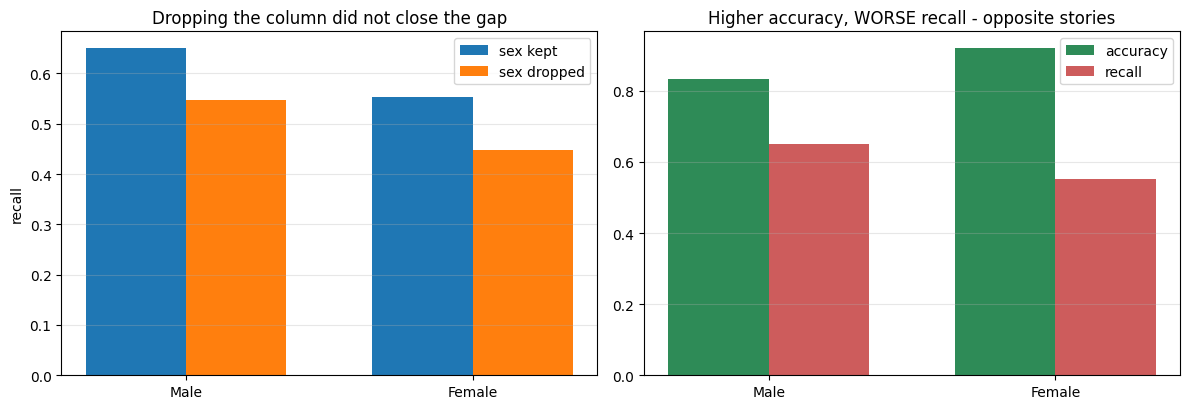

In [9]:
# The picture, because a table this important deserves a chart.
groups = ["Male", "Female"]
x = np.arange(2); w = 0.35

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2))
a1.bar(x - w/2, [before[g] for g in groups], w, label="sex kept")
a1.bar(x + w/2, [after[g] for g in groups], w, label="sex dropped")
a1.set_xticks(x); a1.set_xticklabels(groups); a1.set_ylabel("recall")
a1.set_title("Dropping the column did not close the gap")
a1.legend(); a1.grid(alpha=.3, axis="y")

acc = [accuracy_score(yte[(ste == g).values], pred[(ste == g).values]) for g in groups]
rec = [before[g] for g in groups]
a2.bar(x - w/2, acc, w, label="accuracy", color="seagreen")
a2.bar(x + w/2, rec, w, label="recall", color="indianred")
a2.set_xticks(x); a2.set_xticklabels(groups)
a2.set_title("Higher accuracy, WORSE recall - opposite stories")
a2.legend(); a2.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.show()

### The three fairness definitions genuinely conflict

```text
Demographic parity  - each group gets positive predictions at the same RATE
Equal opportunity   - each group gets the same RECALL
Predictive parity   - each group gets the same PRECISION
```

**You generally cannot satisfy all three at once when the base rates differ between groups.** This is a mathematical result, not an engineering failure. **So you must choose which one your application needs, and say why.**

### The checklist for your capstone

- [ ] Where did this data come from, and was it collected with consent?
- [ ] Does it contain personal information? Should it?
- [ ] Which groups does my data under-represent?
- [ ] Have I measured performance **per group**, not just overall?
- [ ] Can I explain any individual prediction?
- [ ] What is the cost of my model being wrong — and who pays it?
- [ ] Who is accountable when it fails?
- [ ] Have I written the limitations down honestly?

---
# 4. Project grouping, capstone planning and mentoring

🧠 **Cooking for guests for the first time.** You do not attempt a five-course banquet. You cook one dish you can make well, and you make it properly. **A narrow project, finished, beats an ambitious one abandoned — every single time.**

| Property | Test |
|---|---|
| **A real question** | Can you state it in one sentence, with a number or category as the answer? |
| **Data you actually have** | Have you already downloaded it and opened it? |
| **A measurable outcome** | What metric, and what would count as good? |
| **Something to show** | A Streamlit app, a notebook, a report |

> ⚠️ **The commonest failure is choosing a topic before checking the data exists.** Download it first. Open it. Look at the columns. *Then* decide.

In [10]:
# Stage 3 is the one people skip, and it is the cheapest insurance
# in the whole course.
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

df = pd.read_csv(BASE + "loan_data_10k.csv").dropna().reset_index(drop=True)
for c in df.select_dtypes(include="object").columns:
    df[c] = LabelEncoder().fit_transform(df[c])
Xl, yl = df.drop(columns=["loan_status"]), df["loan_status"]

print("class balance:", yl.value_counts(normalize=True).round(3).to_dict())
print("-> balanced, so accuracy is meaningful here.")
print("   At 90/10 you would report RECALL and F1 instead.")

base = cross_val_score(DummyClassifier(strategy="most_frequent"), Xl, yl, cv=5)
print(f"\nbaseline: {base.mean():.4f}")
print("Anything you build must CLEARLY beat this, or it has learned nothing.")
print("Three lines. Run them before you write any modelling code.")

class balance: {0: 0.5, 1: 0.5}
-> balanced, so accuracy is meaningful here.
   At 90/10 you would report RECALL and F1 instead.

baseline: 0.5001
Anything you build must CLEARLY beat this, or it has learned nothing.
Three lines. Run them before you write any modelling code.


In [11]:
# The eight-stage plan, and what each stage owes you.
plan = [
    ("1. Scope",    "pick the question, DOWNLOAD the data", "a paragraph + data on disk"),
    ("2. Explore",  "EDA, missing values, target balance",  "a notebook with charts"),
    ("3. Baseline", "DummyClassifier, then simplest model", "a number to beat"),
    ("4. Model",    "two or three models, cross-validated", "table with mean +/- std"),
    ("5. Evaluate", "bootstrap CI, per-group fairness",     "honest metrics"),
    ("6. Build",    "Streamlit app, ML + GenAI if it fits", "a running app"),
    ("7. Document", "report, model card, README",           "a stranger could follow it"),
    ("8. Present",  "demo and defend it",                   "slides + the live app"),
]
for stage, do, deliver in plan:
    print(f"{stage:<12}{do:<40}-> {deliver}")

print("\n" + "=" * 76)
print("adequate  : a model, a score, a notebook")
print("good      : cross-validated, baselined, working app, honest limitations")
print("EXCELLENT : all that + a fairness audit, a confidence interval,")
print("            a model card, and what you would do next")
print()
print("The gap between good and excellent is almost entirely HONESTY AND")
print("DOCUMENTATION - not a better model. Nobody expects you to beat the")
print("state of the art. They are looking for careful measurement and")
print("faithful reporting.")

1. Scope    pick the question, DOWNLOAD the data    -> a paragraph + data on disk
2. Explore  EDA, missing values, target balance     -> a notebook with charts
3. Baseline DummyClassifier, then simplest model    -> a number to beat
4. Model    two or three models, cross-validated    -> table with mean +/- std
5. Evaluate bootstrap CI, per-group fairness        -> honest metrics
6. Build    Streamlit app, ML + GenAI if it fits    -> a running app
7. Document report, model card, README              -> a stranger could follow it
8. Present  demo and defend it                      -> slides + the live app

adequate  : a model, a score, a notebook
good      : cross-validated, baselined, working app, honest limitations
EXCELLENT : all that + a fairness audit, a confidence interval,
            a model card, and what you would do next

The gap between good and excellent is almost entirely HONESTY AND
DOCUMENTATION - not a better model. Nobody expects you to beat the
state of the art. They are

### Group working

| Role | Owns |
|---|---|
| **Data** | Collection, cleaning, EDA, the data section of the report |
| **Modelling** | Training, evaluation, tuning, the fairness audit |
| **Application** | Streamlit app, integration, deployment |
| **Documentation** | Report, model card, presentation |

> **Rotate at least once.** The point is that everyone learns everything.

**Two rules that prevent most group failures:**

1. **Everyone runs the notebook from a clean start in week one.** Environment problems found in week one are an inconvenience; found the night before submission they are a disaster.
2. **Agree the metric before you build anything.** Arguments about "which model is better" dissolve once the metric is fixed in advance.

### Getting the most from mentoring

Bring: **what you tried** (including failures) · **what you measured** (numbers, not impressions) · **the specific question** · **what you think the answer might be**.

> **"It doesn't work" is not a question.** *"My recall is 0.55 for one group and 0.65 for the other, I tried dropping the sensitive column and it got worse — what should I try next?"* is a question your mentor can answer in two minutes.

---
# ✅ Before you finish the course

**This session**

- [ ] Choosing open or closed weights, with a reason beyond quality
- [ ] Checking a licence before building on a model
- [ ] Loading a model from Hugging Face in three lines
- [ ] Writing a model card, including honest limitations
- [ ] **Auditing fairness per group, never on overall accuracy alone**
- [ ] Knowing that dropping the sensitive column does not remove bias
- [ ] A capstone question, with the data already on your disk

**The whole course**

- [ ] Python: variables through classes *(Session 1)*
- [ ] Loading, exploring and cleaning real data *(Sessions 2–3)*
- [ ] Choosing the right kind of model *(Session 4)*
- [ ] Training, evaluating and saving a model *(Session 5)*
- [ ] Feature engineering, and what each technique costs *(Session 6)*
- [ ] Clustering and finding structure without labels *(Session 7)*
- [ ] Reporting mean ± std, never a gain smaller than the noise *(Session 8)*
- [ ] Having written a neural network from scratch *(Session 9)*
- [ ] Prompting deliberately, and getting structured output *(Session 10)*
- [ ] An app where the model decides and the LLM explains *(Session 11)*
- [ ] **Saying where your model should not be trusted** *(Session 12)*

| | |
|---|---|
| **Previous** | [Session 11 — AI-Powered Applications](../sessions/session-11-ai-apps.md) |
| **All sessions** | [Index](../sessions/README.md) |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |